In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the data

In [3]:
df = pd.read_csv('data/e-shop clothing 2008.csv', sep=';')

Basic Information

In [4]:
print("Shape of data:", df.shape)
print(df.head())
print(df.columns.tolist())
df.info()

Shape of data: (165474, 14)
   year  month  day  order  country  session ID  page 1 (main category)  \
0  2008      4    1      1       29           1                       1   
1  2008      4    1      2       29           1                       1   
2  2008      4    1      3       29           1                       2   
3  2008      4    1      4       29           1                       2   
4  2008      4    1      5       29           1                       2   

  page 2 (clothing model)  colour  location  model photography  price  \
0                     A13       1         5                  1     28   
1                     A16       1         6                  1     33   
2                      B4      10         2                  1     52   
3                     B17       6         6                  2     38   
4                      B8       4         3                  2     52   

   price 2  page  
0        2     1  
1        2     1  
2        1     1  
3     

Missing Values and Duplicates

In [5]:
# Basic info
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.shape)

year                       0
month                      0
day                        0
order                      0
country                    0
session ID                 0
page 1 (main category)     0
page 2 (clothing model)    0
colour                     0
location                   0
model photography          0
price                      0
price 2                    0
page                       0
dtype: int64
0
(165474, 14)


Summary Statistics

In [6]:
print("=== Numerical Summary ===")
print(df.describe())

=== Numerical Summary ===
           year          month            day          order        country  \
count  165474.0  165474.000000  165474.000000  165474.000000  165474.000000   
mean     2008.0       5.585887      14.524554       9.817476      26.952621   
std         0.0       1.328160       8.830374      13.478411       7.150691   
min      2008.0       4.000000       1.000000       1.000000       1.000000   
25%      2008.0       4.000000       7.000000       2.000000      29.000000   
50%      2008.0       5.000000      14.000000       6.000000      29.000000   
75%      2008.0       7.000000      22.000000      12.000000      29.000000   
max      2008.0       8.000000      31.000000     195.000000      47.000000   

          session ID  page 1 (main category)         colour       location  \
count  165474.000000           165474.000000  165474.000000  165474.000000   
mean    12058.417056                2.400842       6.227655       3.258198   
std      7008.418903        

Explore Important Columns

page 1 (main category)
1    49742
4    38747
3    38577
2    38408
Name: count, dtype: int64


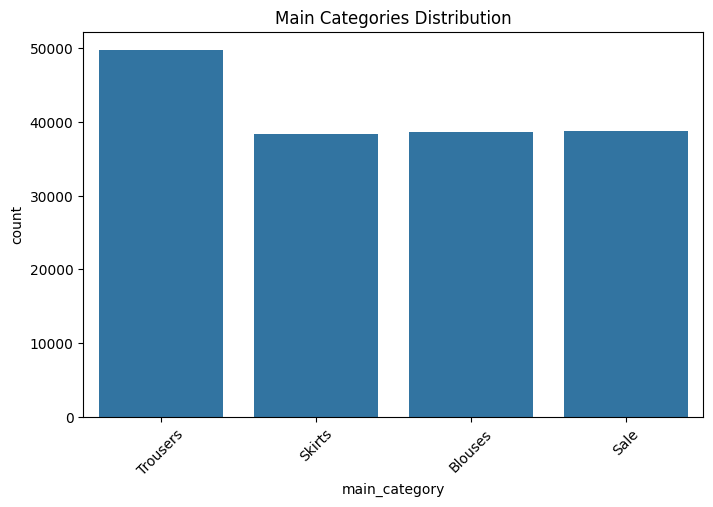

In [7]:
print(df['page 1 (main category)'].value_counts())

# Map category numbers to names for better understanding
category_map = {1: 'Trousers', 2: 'Skirts', 3: 'Blouses', 4: 'Sale'}
df['main_category'] = df['page 1 (main category)'].map(category_map)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='main_category')
plt.title('Main Categories Distribution')
plt.xticks(rotation=45)
plt.show()

Price Analysis

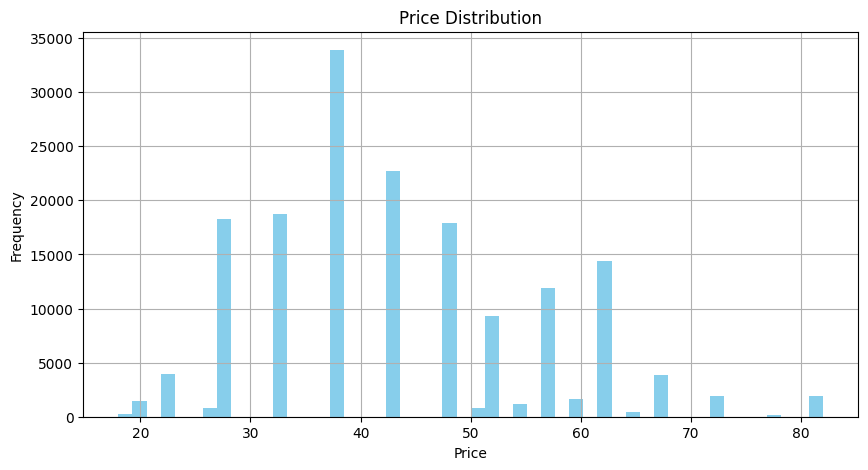

In [8]:
# Price analysis
df['price'].describe()

plt.figure(figsize=(10,5))
df['price'].hist(bins=50, color='skyblue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Country Analysis


=== Top 10 Countries ===
country
29    133963
9      18003
24      4091
46      2522
44      1385
16       834
21       811
34       716
41       684
3        256
Name: count, dtype: int64


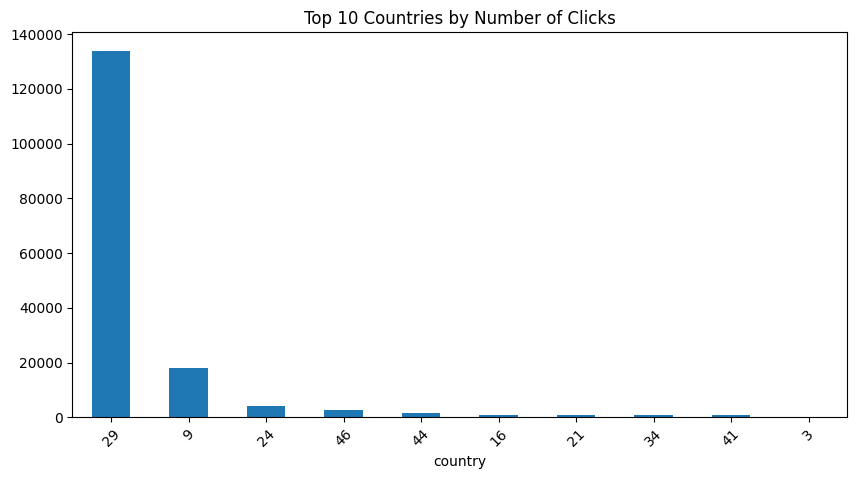

In [9]:
# Country Analysis
print("\n=== Top 10 Countries ===")
print(df['country'].value_counts().head(10))

plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries by Number of Clicks')
plt.xticks(rotation=45)
plt.show()

Session Analysis

In [10]:
print("Total number of sessions:", df['session ID'].nunique())
print("Average clicks per session:", round(len(df) / df['session ID'].nunique(), 2))

# Clicks per session
session_clicks = df.groupby('session ID').size()
print("\nClicks per session - Summary:")
print(session_clicks.describe())

Total number of sessions: 24026
Average clicks per session: 6.89

Clicks per session - Summary:
count    24026.000000
mean         6.887289
std          8.995161
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        195.000000
dtype: float64


Data Analysis

Date Range:
From: 2008-04-01 00:00:00
To: 2008-08-13 00:00:00


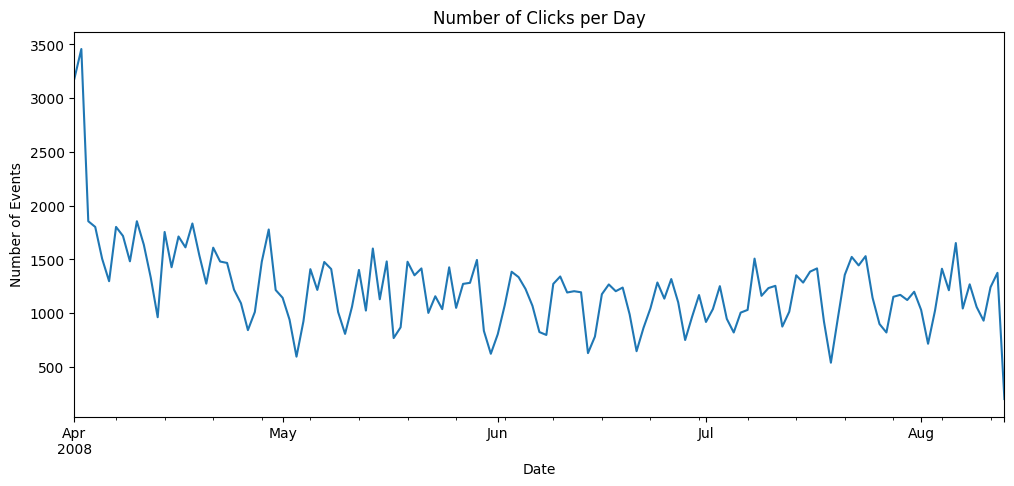

In [11]:
# Create proper date column
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

print("Date Range:")
print("From:", df['date'].min())
print("To:", df['date'].max())

# Events per day
daily = df.groupby('date').size()

plt.figure(figsize=(12,5))
daily.plot()
plt.title('Number of Clicks per Day')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.show()